# PCA Analysis for Tournament Model Data

This notebook performs PCA on `data/tournament_model_ml.csv`, visualizes explained variance and principal components, and saves PCA-transformed train/test datasets as CSV files.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [44]:
# Load the dataset
df = pd.read_csv('data/tournament_model_ml.csv')

features = ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff',
            'TOV_diff', 'TRB_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']

train = df[df['season'] <= 2022].reset_index(drop=True)
test = df[df['season'] >= 2023].reset_index(drop=True)

X_train = train[features]
y_train = train['win_label']
X_test = test[features]
y_test = test['win_label']

print(f'Train rows: {len(train)} | Test rows: {len(test)}')
print('Feature columns:', features)

Train rows: 754 | Test rows: 314
Feature columns: ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff', 'TOV_diff', 'TRB_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']


# PCA Analysis for Tournament Model Data

# PCA Analysis for Tournament Model Data

This notebook performs PCA on `data/tournament_model_ml.csv`, visualizes explained variance and principal components, and saves PCA-transformed train/test datasets as CSV files.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [46]:
# Load the dataset
df = pd.read_csv('data/tournament_model_ml.csv')

features = ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff',
            'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']

train = df[df['season'] <= 2022].reset_index(drop=True)
test = df[df['season'] >= 2023].reset_index(drop=True)

X_train = train[features]
y_train = train['win_label']
X_test = test[features]
y_test = test['win_label']

print(f'Train rows: {len(train)} | Test rows: {len(test)}')
print('Feature columns:', features)

Train rows: 754 | Test rows: 314
Feature columns: ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff', 'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']


In [47]:
# Fit PCA with scaling on the training set
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

pipeline.fit(X_train)
pca = pipeline.named_steps['pca']
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Explained variance ratio by principal component:')
for i, ratio in enumerate(explained_variance, start=1):
    print(f'  PC{i}: {ratio:.4f}')

print('\nCumulative explained variance:')
for i, cum in enumerate(cumulative_variance, start=1):
    print(f'  PC{i}: {cum:.4f}')

Explained variance ratio by principal component:
  PC1: 0.4353
  PC2: 0.2009
  PC3: 0.1224
  PC4: 0.0830
  PC5: 0.0552
  PC6: 0.0399
  PC7: 0.0372
  PC8: 0.0194
  PC9: 0.0066

Cumulative explained variance:
  PC1: 0.4353
  PC2: 0.6362
  PC3: 0.7586
  PC4: 0.8416
  PC5: 0.8968
  PC6: 0.9368
  PC7: 0.9739
  PC8: 0.9934
  PC9: 1.0000


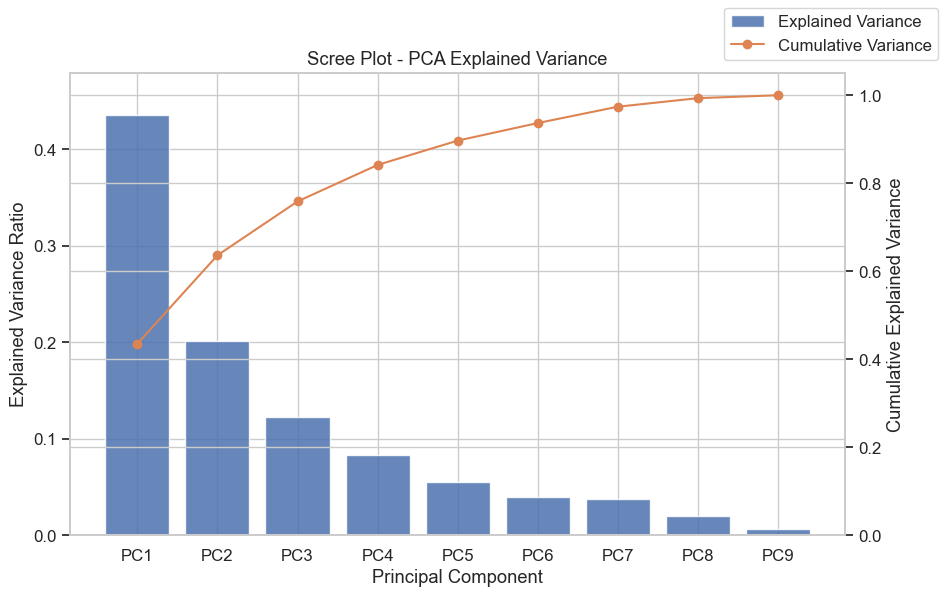

In [48]:
# Scree plot and cumulative variance plot
pc_labels = [f'PC{i+1}' for i in range(len(explained_variance))]

fig, ax1 = plt.subplots()
ax1.bar(pc_labels, explained_variance, color='#4c72b0', alpha=0.85, label='Explained Variance')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_xlabel('Principal Component')
ax1.set_title('Scree Plot - PCA Explained Variance')
ax1.set_ylim(0, explained_variance.max() * 1.1)

ax2 = ax1.twinx()
ax2.plot(pc_labels, cumulative_variance, color='#dd8452', marker='o', label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_ylim(0, 1.05)

fig.legend(loc='upper right')
plt.show()

In [49]:
# Project the data onto the first three principal components
n_components = 3
pca_model = PCA(n_components=n_components)
X_train_scaled = pipeline.named_steps['scaler'].transform(X_train)
X_train_pca = pd.DataFrame(
    pca_model.fit_transform(X_train_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_train.index
)
train_pca_inspect = pd.concat([train[['season', 'win_label']].reset_index(drop=True), X_train_pca.reset_index(drop=True)], axis=1)
train_pca_inspect.head()

,season,win_label,PC1,PC2,PC3
0,2015,1,2.800673,1.728798,-1.613391
1,2015,1,1.595223,-1.375904,-0.320133
2,2015,1,0.502696,2.005143,-2.216379
3,2015,1,0.239608,-0.864773,1.263662
4,2015,1,1.691296,1.660130,-0.762817


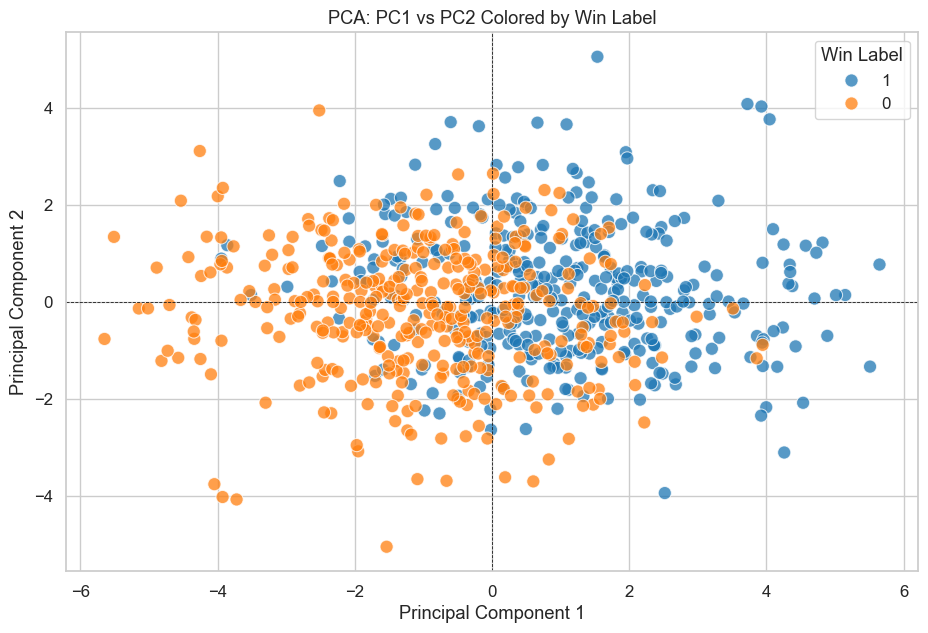

In [50]:
# 2D scatter plot for PC1 vs PC2
pca_train_plot = train_pca_inspect.copy()
pca_train_plot['win_label'] = pca_train_plot['win_label'].astype(str)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=pca_train_plot,
    x='PC1',
    y='PC2',
    hue='win_label',
    palette=['#1f77b4', '#ff7f0e'],
    alpha=0.75,
    edgecolor='w',
    s=90
)
plt.title('PCA: PC1 vs PC2 Colored by Win Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Win Label')
plt.axhline(0, color='k', linewidth=0.6, linestyle='--')
plt.axvline(0, color='k', linewidth=0.6, linestyle='--')
plt.show()

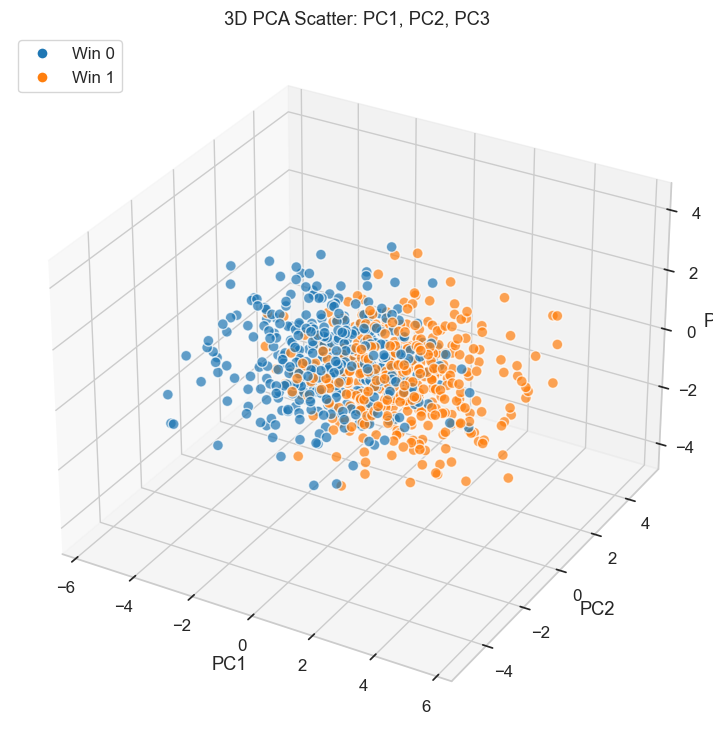

In [51]:
# 3D scatter plot for PC1, PC2, and PC3
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
colors = pca_train_plot['win_label'].map({'0': '#1f77b4', '1': '#ff7f0e'})

ax.scatter(
    pca_train_plot['PC1'],
    pca_train_plot['PC2'],
    pca_train_plot['PC3'],
    c=colors,
    s=60,
    alpha=0.7,
    edgecolors='w'
)
ax.set_title('3D PCA Scatter: PC1, PC2, PC3')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Win 0', markerfacecolor='#1f77b4', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Win 1', markerfacecolor='#ff7f0e', markersize=8)
]
ax.legend(handles=legend_elements, loc='upper left')
plt.show()

In [52]:
# Feature loadings for the first three principal components
loadings = pd.DataFrame(
    pca_model.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(n_components)]
)
loadings.round(3)

,PC1,PC2,PC3
3P%_diff,0.246,-0.435,0.388
AST_diff,0.406,0.080,0.334
FG%_diff,0.353,-0.265,0.427
FT%_diff,0.135,-0.433,-0.254
SRS_diff,0.433,0.105,-0.367
TOV_diff,0.006,0.542,0.417
TRB_diff,0.328,0.473,0.010
seed_diff,-0.414,-0.117,0.424
win_pct_diff,0.407,-0.064,-0.046


In [53]:
# Transform the test set with the same scaler and PCA model
X_test_scaled = pipeline.named_steps['scaler'].transform(X_test)
X_test_pca = pd.DataFrame(
    pca_model.transform(X_test_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_test.index
)

print('X_train_pca shape:', X_train_pca.shape)
print('X_test_pca shape:', X_test_pca.shape)

X_train_pca.head()

X_train_pca shape: (754, 3)
X_test_pca shape: (314, 3)


,PC1,PC2,PC3
0,2.800673,1.728798,-1.613391
1,1.595223,-1.375904,-0.320133
2,0.502696,2.005143,-2.216379
3,0.239608,-0.864773,1.263662
4,1.691296,1.660130,-0.762817


In [54]:
# Save PCA-transformed datasets to CSV files
X_train_pca.to_csv('data/pca_train_ml.csv', index=False)
X_test_pca.to_csv('data/pca_test_ml.csv', index=False)

combined_pca = pd.concat([
    X_train_pca.assign(dataset='train', win_label=y_train.values, season=train['season'].values),
    X_test_pca.assign(dataset='test', win_label=y_test.values, season=test['season'].values)
], axis=0).reset_index(drop=True)
combined_pca.to_csv('data/pca_all_ml.csv', index=False)

print('Saved X_train_pca to data/pca_train_ml.csv')
print('Saved X_test_pca to data/pca_test_ml.csv')
print('Saved combined PCA dataset to data/pca_all_ml.csv')

Saved X_train_pca to data/pca_train_ml.csv
Saved X_test_pca to data/pca_test_ml.csv
Saved combined PCA dataset to data/pca_all_ml.csv


In [55]:
# Save the full PCA DataFrame to CSV
combined_pca.to_csv('data/pca_df.csv', index=False)
print('Saved PCA combined dataframe to data/pca_df.csv')

Saved PCA combined dataframe to data/pca_df.csv


## Ready for Random Forest Modeling

The PCA-transformed datasets are `X_train_pca` and `X_test_pca`, with targets `y_train` and `y_test`. These can be passed directly into a random forest model with the same training/test structure used in `randomforest.ipynb`.

# PCA Analysis for Tournament Model Data

This notebook performs PCA on `data/tournament_model_ml.csv`, visualizes explained variance and the principal component scores, and produces PCA-transformed train/test datasets that are ready for a random forest pipeline.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [57]:
# Load the dataset
df = pd.read_csv('data/tournament_model_ml.csv')

features = ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff',
            'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']

train = df[df['season'] <= 2022].reset_index(drop=True)
test = df[df['season'] >= 2023].reset_index(drop=True)

X_train = train[features]
y_train = train['win_label']
X_test = test[features]
y_test = test['win_label']

print(f'Train rows: {len(train)} | Test rows: {len(test)}')
print('Feature columns:', features)

Train rows: 754 | Test rows: 314
Feature columns: ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff', 'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']


In [58]:
# Fit PCA with scaling on the training set
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

pipeline.fit(X_train)
pca = pipeline.named_steps['pca']
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Explained variance ratio by principal component:')
for i, ratio in enumerate(explained_variance, start=1):
    print(f'  PC{i}: {ratio:.4f}')

print('\nCumulative explained variance:')
for i, cum in enumerate(cumulative_variance, start=1):
    print(f'  PC{i}: {cum:.4f}')

Explained variance ratio by principal component:
  PC1: 0.4353
  PC2: 0.2009
  PC3: 0.1224
  PC4: 0.0830
  PC5: 0.0552
  PC6: 0.0399
  PC7: 0.0372
  PC8: 0.0194
  PC9: 0.0066

Cumulative explained variance:
  PC1: 0.4353
  PC2: 0.6362
  PC3: 0.7586
  PC4: 0.8416
  PC5: 0.8968
  PC6: 0.9368
  PC7: 0.9739
  PC8: 0.9934
  PC9: 1.0000


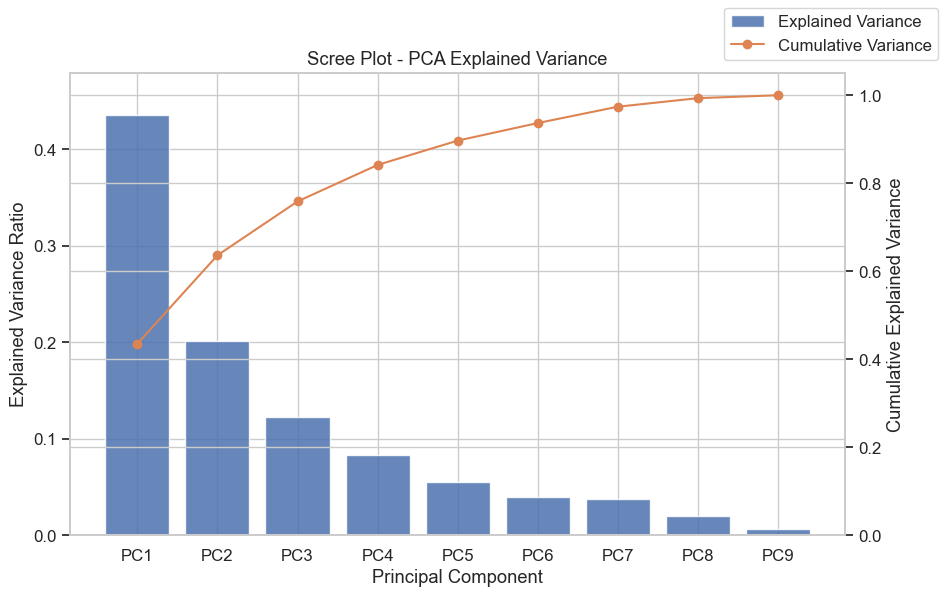

In [59]:
# Scree plot and cumulative variance plot
pc_labels = [f'PC{i+1}' for i in range(len(explained_variance))]

fig, ax1 = plt.subplots()
ax1.bar(pc_labels, explained_variance, color='#4c72b0', alpha=0.85, label='Explained Variance')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_xlabel('Principal Component')
ax1.set_title('Scree Plot - PCA Explained Variance')
ax1.set_ylim(0, explained_variance.max() * 1.1)

ax2 = ax1.twinx()
ax2.plot(pc_labels, cumulative_variance, color='#dd8452', marker='o', label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_ylim(0, 1.05)

fig.legend(loc='upper right')
plt.show()

In [60]:
# Project the data onto the first three principal components
n_components = 3
pca_model = PCA(n_components=n_components)
X_train_scaled = pipeline.named_steps['scaler'].transform(X_train)
X_train_pca = pd.DataFrame(
    pca_model.fit_transform(X_train_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_train.index
)
train_pca_inspect = pd.concat([train[['season', 'win_label']].reset_index(drop=True), X_train_pca.reset_index(drop=True)], axis=1)
train_pca_inspect.head()

,season,win_label,PC1,PC2,PC3
0,2015,1,2.800673,1.728798,-1.613391
1,2015,1,1.595223,-1.375904,-0.320133
2,2015,1,0.502696,2.005143,-2.216379
3,2015,1,0.239608,-0.864773,1.263662
4,2015,1,1.691296,1.660130,-0.762817


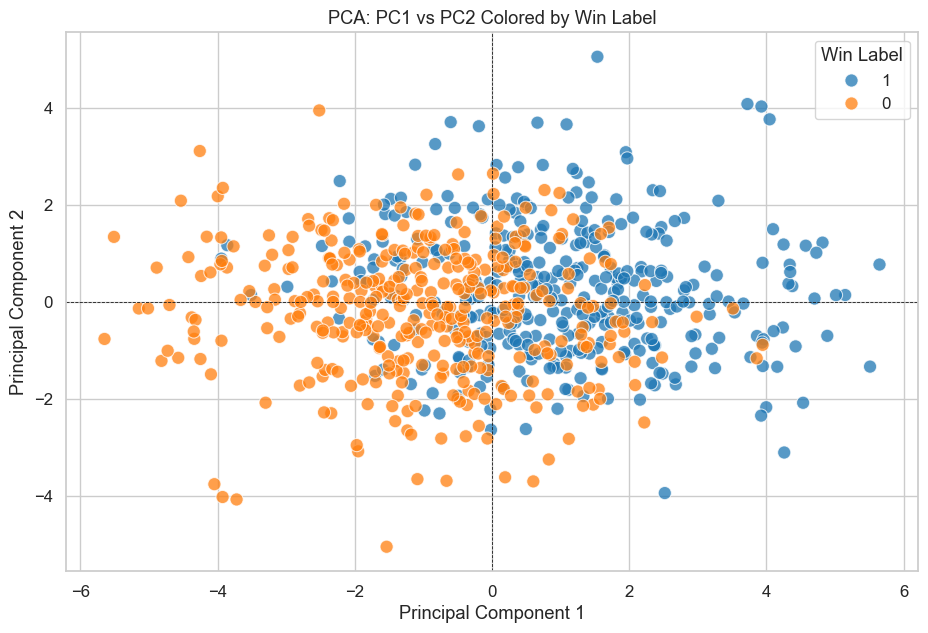

In [61]:
# 2D scatter plot for PC1 vs PC2
pca_train_plot = train_pca_inspect.copy()
pca_train_plot['win_label'] = pca_train_plot['win_label'].astype(str)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=pca_train_plot,
    x='PC1',
    y='PC2',
    hue='win_label',
    palette=['#1f77b4', '#ff7f0e'],
    alpha=0.75,
    edgecolor='w',
    s=90
)
plt.title('PCA: PC1 vs PC2 Colored by Win Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Win Label')
plt.axhline(0, color='k', linewidth=0.6, linestyle='--')
plt.axvline(0, color='k', linewidth=0.6, linestyle='--')
plt.show()

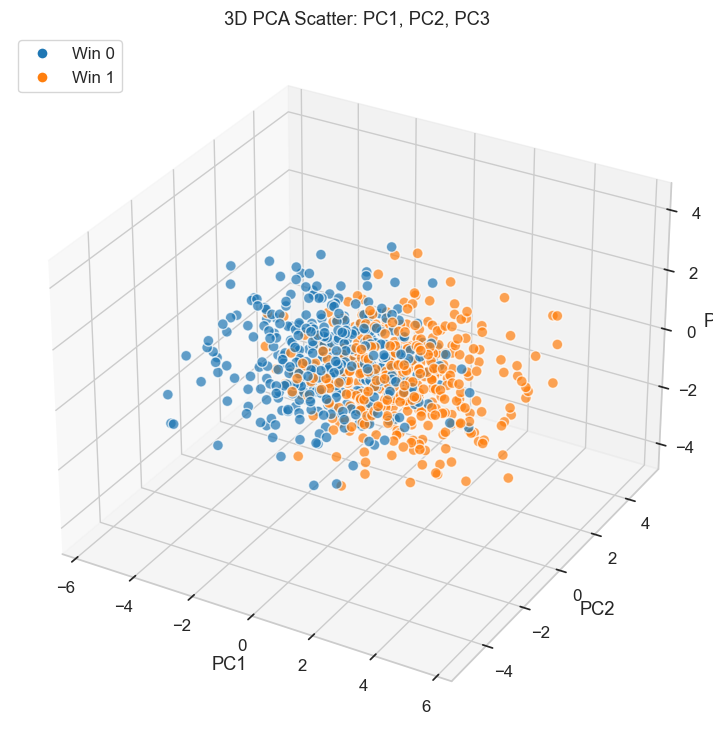

In [62]:
# 3D scatter plot for PC1, PC2, and PC3
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
colors = pca_train_plot['win_label'].map({'0': '#1f77b4', '1': '#ff7f0e'})

ax.scatter(
    pca_train_plot['PC1'],
    pca_train_plot['PC2'],
    pca_train_plot['PC3'],
    c=colors,
    s=60,
    alpha=0.7,
    edgecolors='w'
)
ax.set_title('3D PCA Scatter: PC1, PC2, PC3')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Win 0', markerfacecolor='#1f77b4', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Win 1', markerfacecolor='#ff7f0e', markersize=8)
]
ax.legend(handles=legend_elements, loc='upper left')
plt.show()

In [63]:
# Feature loadings for the first three principal components
loadings = pd.DataFrame(
    pca_model.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(n_components)]
)
loadings.round(3)

,PC1,PC2,PC3
3P%_diff,0.246,-0.435,0.388
AST_diff,0.406,0.080,0.334
FG%_diff,0.353,-0.265,0.427
FT%_diff,0.135,-0.433,-0.254
SRS_diff,0.433,0.105,-0.367
TOV_diff,0.006,0.542,0.417
TRB_diff,0.328,0.473,0.010
seed_diff,-0.414,-0.117,0.424
win_pct_diff,0.407,-0.064,-0.046


In [64]:
# Transform the test set with the same scaler and PCA model
X_test_scaled = pipeline.named_steps['scaler'].transform(X_test)
X_test_pca = pd.DataFrame(
    pca_model.transform(X_test_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_test.index
)

print('X_train_pca shape:', X_train_pca.shape)
print('X_test_pca shape:', X_test_pca.shape)

X_train_pca.head()

X_train_pca shape: (754, 3)
X_test_pca shape: (314, 3)


,PC1,PC2,PC3
0,2.800673,1.728798,-1.613391
1,1.595223,-1.375904,-0.320133
2,0.502696,2.005143,-2.216379
3,0.239608,-0.864773,1.263662
4,1.691296,1.660130,-0.762817


## Ready for Random Forest Modeling

The PCA-transformed datasets are `X_train_pca` and `X_test_pca`, with targets `y_train` and `y_test`. These can be passed directly into a random forest model with the same training/test structure used in `randomforest.ipynb`.

# PCA Analysis for Tournament Model Data

This notebook performs principal component analysis on `data/tournament_model_ml.csv`, shows explained variance and component structure, and produces PCA-transformed train/test sets that are ready to plug into a random forest pipeline.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [66]:
# Load the dataset
df = pd.read_csv('data/tournament_model_ml.csv')

# Define the feature set used for PCA
features = ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff',
            'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']

# Train/test split by season to mirror the modeling approach in randomforest.ipynb
train = df[df['season'] <= 2022].reset_index(drop=True)
test = df[df['season'] >= 2023].reset_index(drop=True)

X_train = train[features]
y_train = train['win_label']
X_test = test[features]
y_test = test['win_label']

print(f'Train rows: {len(train)} | Test rows: {len(test)}')
print('Feature columns:', features)

Train rows: 754 | Test rows: 314
Feature columns: ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff', 'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']


In [67]:
# Build a pipeline with scaling and PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

pca_pipeline.fit(X_train)
pca = pca_pipeline.named_steps['pca']
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Explained variance ratio by principal component:')
for i, ratio in enumerate(explained_variance, start=1):
    print(f'  PC{i}: {ratio:.4f}')

print('\nCumulative explained variance:')
for i, cum in enumerate(cumulative_variance, start=1):
    print(f'  PC{i}: {cum:.4f}')

Explained variance ratio by principal component:
  PC1: 0.4353
  PC2: 0.2009
  PC3: 0.1224
  PC4: 0.0830
  PC5: 0.0552
  PC6: 0.0399
  PC7: 0.0372
  PC8: 0.0194
  PC9: 0.0066

Cumulative explained variance:
  PC1: 0.4353
  PC2: 0.6362
  PC3: 0.7586
  PC4: 0.8416
  PC5: 0.8968
  PC6: 0.9368
  PC7: 0.9739
  PC8: 0.9934
  PC9: 1.0000


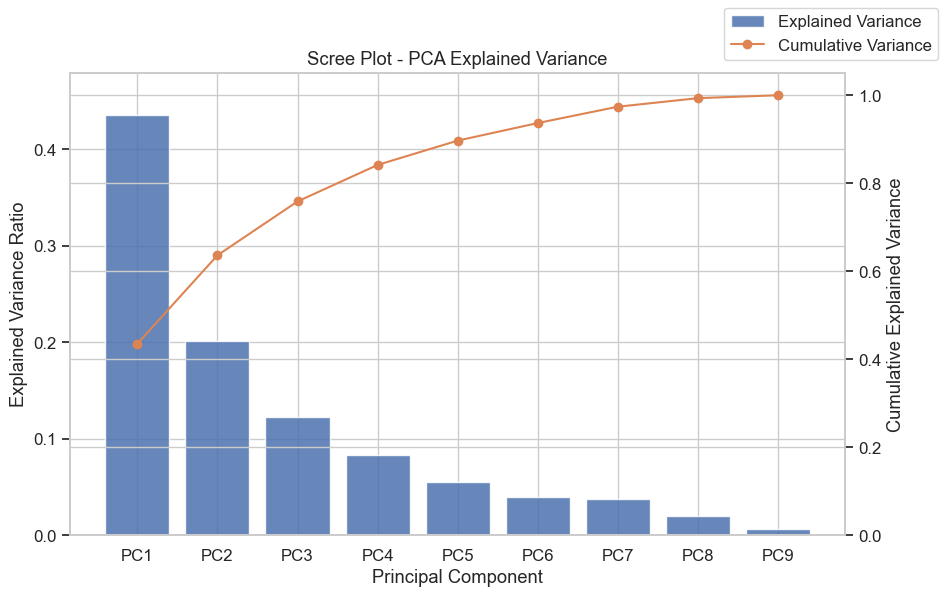

In [68]:
# Visualize the explained variance
pc_labels = [f'PC{i+1}' for i in range(len(explained_variance))]

fig, ax1 = plt.subplots()
ax1.bar(pc_labels, explained_variance, color='#4c72b0', alpha=0.85, label='Explained Variance')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_xlabel('Principal Component')
ax1.set_title('Scree Plot - PCA Explained Variance')
ax1.set_ylim(0, explained_variance.max() * 1.1)

ax2 = ax1.twinx()
ax2.plot(pc_labels, cumulative_variance, color='#dd8452', marker='o', label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_ylim(0, 1.05)

fig.legend(loc='upper right')
plt.show()

In [69]:
# Build a DataFrame with PCA scores for the training data
n_components = 3

pca_model = PCA(n_components=n_components)
X_train_scaled = pca_pipeline.named_steps['scaler'].transform(X_train)
X_train_pca = pd.DataFrame(
    pca_model.fit_transform(X_train_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_train.index
)

# Attach the target and season for inspection only
train_pca_inspect = pd.concat([train[['season', 'win_label']].reset_index(drop=True), X_train_pca.reset_index(drop=True)], axis=1)
train_pca_inspect.head()

,season,win_label,PC1,PC2,PC3
0,2015,1,2.800673,1.728798,-1.613391
1,2015,1,1.595223,-1.375904,-0.320133
2,2015,1,0.502696,2.005143,-2.216379
3,2015,1,0.239608,-0.864773,1.263662
4,2015,1,1.691296,1.660130,-0.762817


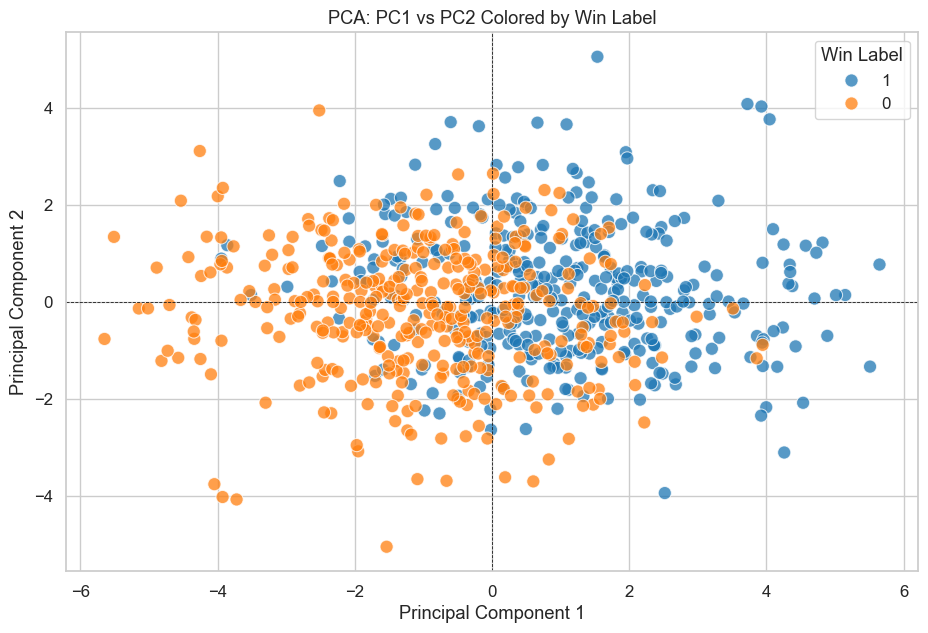

In [70]:
# Scatter plot of the first two principal components
pca_train_plot = train_pca_inspect.copy()
pca_train_plot['win_label'] = pca_train_plot['win_label'].astype(str)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=pca_train_plot,
    x='PC1',
    y='PC2',
    hue='win_label',
    palette=['#1f77b4', '#ff7f0e'],
    alpha=0.75,
    edgecolor='w',
    s=90
)
plt.title('PCA: PC1 vs PC2 Colored by Win Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Win Label')
plt.axhline(0, color='k', linewidth=0.6, linestyle='--')
plt.axvline(0, color='k', linewidth=0.6, linestyle='--')
plt.show()

In [71]:
# Compare feature loadings for the first three principal components
loadings = pd.DataFrame(
    pca_model.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

loadings.round(3)

,PC1,PC2,PC3
3P%_diff,0.246,-0.435,0.388
AST_diff,0.406,0.080,0.334
FG%_diff,0.353,-0.265,0.427
FT%_diff,0.135,-0.433,-0.254
SRS_diff,0.433,0.105,-0.367
TOV_diff,0.006,0.542,0.417
TRB_diff,0.328,0.473,0.010
seed_diff,-0.414,-0.117,0.424
win_pct_diff,0.407,-0.064,-0.046


In [72]:
# Transform the test set with the same scaler and PCA model
X_test_scaled = pca_pipeline.named_steps['scaler'].transform(X_test)
X_test_pca = pd.DataFrame(
    pca_model.transform(X_test_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_test.index
)

# Show the ready-to-use PCA datasets for random forest modeling
print('X_train_pca shape:', X_train_pca.shape)
print('X_test_pca shape:', X_test_pca.shape)

X_train_pca.head()

X_train_pca shape: (754, 3)
X_test_pca shape: (314, 3)


,PC1,PC2,PC3
0,2.800673,1.728798,-1.613391
1,1.595223,-1.375904,-0.320133
2,0.502696,2.005143,-2.216379
3,0.239608,-0.864773,1.263662
4,1.691296,1.660130,-0.762817


## Ready for Random Forest Modeling

The PCA-transformed inputs are stored in `X_train_pca` and `X_test_pca`, and the target vectors are `y_train` and `y_test`. This matches the training pattern used in `randomforest.ipynb`, but with the original feature set replaced by the top principal components.

# PCA Analysis for Tournament Model Data

This notebook performs principal component analysis on `data/tournament_model_ml.csv`, shows the explained variance and component structure, and produces PCA-transformed train/test sets that are ready to plug into a random forest pipeline.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [74]:
# Load the dataset
df = pd.read_csv('data/tournament_model_ml.csv')

# Define the feature set used for PCA
features = ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff',
            'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']

# Train/test split by season to mirror the modeling approach in randomforest.ipynb
train = df[df['season'] <= 2022].reset_index(drop=True)
test = df[df['season'] >= 2023].reset_index(drop=True)

X_train = train[features]
y_train = train['win_label']
X_test = test[features]
y_test = test['win_label']

print(f'Train rows: {len(train)} | Test rows: {len(test)}')
print('Feature columns:', features)

Train rows: 754 | Test rows: 314
Feature columns: ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff', 'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']


In [75]:
# Build a pipeline with scaling and PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

pca_pipeline.fit(X_train)
pca = pca_pipeline.named_steps['pca']
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Explained variance ratio by principal component:')
for i, ratio in enumerate(explained_variance, start=1):
    print(f'  PC{i}: {ratio:.4f}')

print('\nCumulative explained variance:')
for i, cum in enumerate(cumulative_variance, start=1):
    print(f'  PC{i}: {cum:.4f}')

Explained variance ratio by principal component:
  PC1: 0.4353
  PC2: 0.2009
  PC3: 0.1224
  PC4: 0.0830
  PC5: 0.0552
  PC6: 0.0399
  PC7: 0.0372
  PC8: 0.0194
  PC9: 0.0066

Cumulative explained variance:
  PC1: 0.4353
  PC2: 0.6362
  PC3: 0.7586
  PC4: 0.8416
  PC5: 0.8968
  PC6: 0.9368
  PC7: 0.9739
  PC8: 0.9934
  PC9: 1.0000


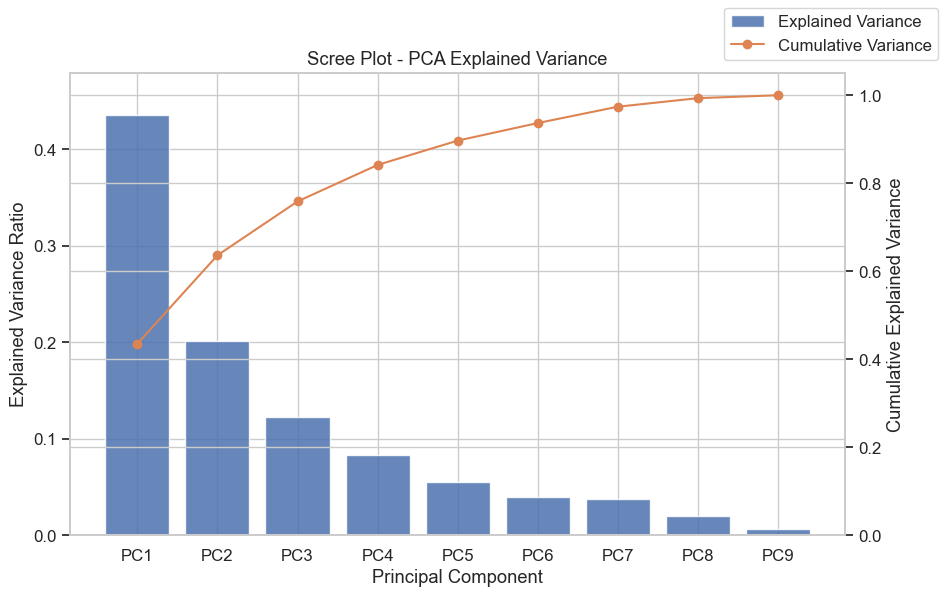

In [76]:
# Visualize the explained variance
pc_labels = [f'PC{i+1}' for i in range(len(explained_variance))]

fig, ax1 = plt.subplots()
ax1.bar(pc_labels, explained_variance, color='#4c72b0', alpha=0.85, label='Explained Variance')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_xlabel('Principal Component')
ax1.set_title('Scree Plot - PCA Explained Variance')
ax1.set_ylim(0, explained_variance.max() * 1.1)

ax2 = ax1.twinx()
ax2.plot(pc_labels, cumulative_variance, color='#dd8452', marker='o', label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_ylim(0, 1.05)

fig.legend(loc='upper right')
plt.show()

In [77]:
# Build a DataFrame with PCA scores for the training data
n_components = 3

pca_model = PCA(n_components=n_components)
X_train_scaled = pca_pipeline.named_steps['scaler'].transform(X_train)
X_train_pca = pd.DataFrame(
    pca_model.fit_transform(X_train_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_train.index
)

# Attach the target and season for inspection only
train_pca_inspect = pd.concat([train[['season', 'win_label']].reset_index(drop=True), X_train_pca.reset_index(drop=True)], axis=1)
train_pca_inspect.head()

,season,win_label,PC1,PC2,PC3
0,2015,1,2.800673,1.728798,-1.613391
1,2015,1,1.595223,-1.375904,-0.320133
2,2015,1,0.502696,2.005143,-2.216379
3,2015,1,0.239608,-0.864773,1.263662
4,2015,1,1.691296,1.660130,-0.762817


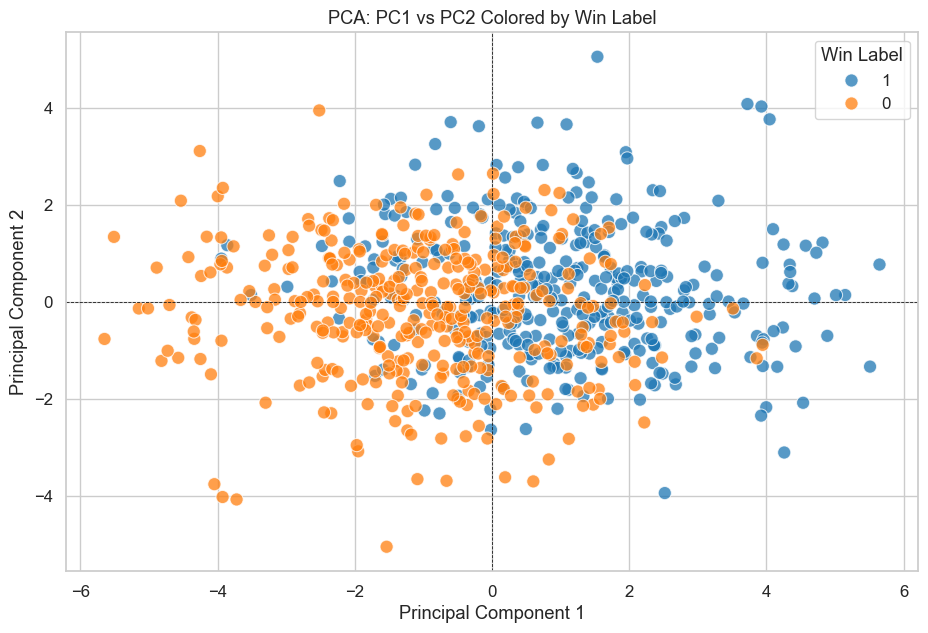

In [78]:
# Scatter plot of the first two principal components
pca_train_plot = train_pca_inspect.copy()
pca_train_plot['win_label'] = pca_train_plot['win_label'].astype(str)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=pca_train_plot,
    x='PC1',
    y='PC2',
    hue='win_label',
    palette=['#1f77b4', '#ff7f0e'],
    alpha=0.75,
    edgecolor='w',
    s=90
)
plt.title('PCA: PC1 vs PC2 Colored by Win Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Win Label')
plt.axhline(0, color='k', linewidth=0.6, linestyle='--')
plt.axvline(0, color='k', linewidth=0.6, linestyle='--')
plt.show()

In [79]:
# Compare feature loadings for the first three principal components
loadings = pd.DataFrame(
    pca_model.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

loadings.round(3)

,PC1,PC2,PC3
3P%_diff,0.246,-0.435,0.388
AST_diff,0.406,0.080,0.334
FG%_diff,0.353,-0.265,0.427
FT%_diff,0.135,-0.433,-0.254
SRS_diff,0.433,0.105,-0.367
TOV_diff,0.006,0.542,0.417
TRB_diff,0.328,0.473,0.010
seed_diff,-0.414,-0.117,0.424
win_pct_diff,0.407,-0.064,-0.046


In [80]:
# Transform the test set with the same scaler and PCA model
X_test_scaled = pca_pipeline.named_steps['scaler'].transform(X_test)
X_test_pca = pd.DataFrame(
    pca_model.transform(X_test_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_test.index
)

# Show the ready-to-use PCA datasets for random forest modeling
print('X_train_pca shape:', X_train_pca.shape)
print('X_test_pca shape:', X_test_pca.shape)

X_train_pca.head()

X_train_pca shape: (754, 3)
X_test_pca shape: (314, 3)


,PC1,PC2,PC3
0,2.800673,1.728798,-1.613391
1,1.595223,-1.375904,-0.320133
2,0.502696,2.005143,-2.216379
3,0.239608,-0.864773,1.263662
4,1.691296,1.660130,-0.762817


## Ready for Random Forest Modeling

The PCA-transformed inputs are stored in `X_train_pca` and `X_test_pca`, and the target vectors are `y_train` and `y_test`. This matches the training pattern used in `randomforest.ipynb`, but with the original feature set replaced by the top principal components.